# 01_03 · EDA — Dataset CNC Industrial (KIT Karlsruhe)

**Dataset**: A Multimodal Dataset for Process Monitoring and Anomaly Detection in Industrial CNC Milling
**Fuente**: Instituto Leibniz / FIZ Karlsruhe, 2025 · DOI: 10.35097/hvvwn1kfwf7qt48z
**Máquina**: CNC de 5 ejes (ejes X=1, Y=2, Z=3, husillo=6)
**Frecuencia de muestreo**: 500 Hz
**Experimentos**: 18 ficheros disponibles (8 normales, 10 anomalías de 5 tipos)

Señales monitorizadas: `TORQUE`, `CURRENT`, `POWER`, `LOAD` × 4 ejes

**Conexión con el resto del proyecto:**
- `TORQUE|6` ↔ AI4I `Torque [Nm]`
- `POWER|6` ↔ AI4I feature `Power [W]`
- `CURRENT|6` ↔ SPARK `I1, I2, I3`
- `POWER|6` ↔ SPARK `P_total`


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
%matplotlib inline

KIT_DIR   = os.path.join('..', 'data', 'raw', 'kit_extracted')
PROC_DIR  = os.path.join('..', 'data', 'processed')
os.makedirs(PROC_DIR, exist_ok=True)

KEY_SIGNALS = [
    'TORQUE|1','TORQUE|2','TORQUE|3','TORQUE|6',
    'CURRENT|1','CURRENT|2','CURRENT|3','CURRENT|6',
    'POWER|1','POWER|2','POWER|3','POWER|6',
    'LOAD|1','LOAD|2','LOAD|3','LOAD|6',
]

# Etiquetas multi-clase — 33 experimentos completos
FAULT_TYPE = {
    # 0 — Normal
    'IM-01F': 0, 'IM-01R': 0,
    'IMP-01': 0, 'IMP-02': 0, 'IMP-03': 0, 'IMP-04': 0,
    'IMP-05': 0, 'IMP-06': 0, 'IMP-07': 0, 'IMP-08': 0,
    'IMP-09': 0, 'IMP-10': 0, 'IMP-11': 0, 'IMP-12': 0, 'IMP-BASE': 0,
    'TF-01': 0, 'TF-02': 0, 'TF-03': 0,
    # 1 — Tool Wear
    'IM-01R-A01': 1, 'IM-01R-A02': 1, 'IM-01R-A03': 1,
    'IM-01R-A04': 1, 'IM-01R-A05': 1,
    # 2 — Chatter
    'IM-02F-A01': 2,
    # 3 — Process Anomaly (overload, feedrate, built-up edge, stock)
    'IM-01F-A01': 3, 'TF-01-A01': 3, 'TF-02-A01': 3,
    'TF-03-A01': 3, 'TF-03-A02': 3,
    # 4 — Workpiece Defect (cavity, crack, chipped edge)
    'IMP-01-A01': 4, 'IMP-01-A02': 4, 'IMP-01-A03': 4, 'IMP-01-A04': 4,
}
FAULT_NAMES  = {0:'Normal', 1:'Tool Wear', 2:'Chatter',
                3:'Process Anomaly', 4:'Workpiece Defect'}
FAULT_COLORS = {0:'#3498db', 1:'#e74c3c', 2:'#e67e22', 3:'#9b59b6', 4:'#2ecc71'}
BINARY = {t: int(l > 0) for t, l in FAULT_TYPE.items()}

def load_kit(trial):
    path = os.path.join(KIT_DIR, f'{trial}_hfdata.csv')
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    df['trial']      = trial
    df['fault_type'] = FAULT_TYPE.get(trial, -1)
    df['anomaly']    = BINARY.get(trial, -1)
    return df

TRIALS = sorted(FAULT_TYPE.keys())
n_norm = sum(v==0 for v in FAULT_TYPE.values())
n_anom = sum(v>0  for v in FAULT_TYPE.values())
print(f'Trials: {len(TRIALS)} ({n_norm} normales, {n_anom} anomalias)')
print(f'Por tipo: { {FAULT_NAMES[k]: sum(v==k for v in FAULT_TYPE.values()) for k in FAULT_NAMES} }')


Trials: 33 (18 normales, 15 anomalias)
Por tipo: {'Normal': 18, 'Tool Wear': 5, 'Chatter': 1, 'Process Anomaly': 5, 'Workpiece Defect': 4}


## 1. Carga y visión general

Cargamos los 18 ficheros disponibles y verificamos:
- **Dimensiones**: cada fichero es una serie temporal a 500 Hz de todo el experimento
- **Columnas disponibles**: 61 señales internas del CNC (torque, corriente, potencia, posición, carga)
- **Valores nulos**: pueden aparecer en ejes que no participan en un tramo concreto del mecanizado

La columna `CYCLE` es el contador de ciclos del CNC — permite segmentar el experimento
por pasadas de mecanizado sin necesidad de timestamp explícito.

In [31]:
summary = []
for t in TRIALS:
    df = load_kit(t)
    if df is None:
        print(f'  ⚠ No encontrado: {t}')
        continue
    avail = [s for s in KEY_SIGNALS if s in df.columns]
    summary.append({
        'Trial': t,
        'Tipo': FAULT_NAMES[FAULT_TYPE[t]],
        'Filas': len(df),
        'Dur. aprox (s)': round(len(df)/500),
        'Señales disp.': len(avail),
        'NaN (%)': round(df[avail].isnull().mean().mean()*100, 1),
    })

df_sum = pd.DataFrame(summary)
df_sum.head(5)
print(f'\nTotal filas: {df_sum["Filas"].sum():,}')
print(f'Total tiempo: ~{df_sum["Dur. aprox (s)"].sum()/60:.0f} minutos de mecanizado')


Total filas: 8,073,040
Total tiempo: ~269 minutos de mecanizado


## 2. Series temporales — ¿qué aspecto tienen normal vs. anomalía?

Antes de extraer estadísticos, es fundamental ver las señales en crudo.
Las series temporales revelan la *morfología* de cada tipo de anomalía:

- **Tool Wear**: torque gradualmente más alto y variable — la herramienta se esfuerza más
- **Chatter**: oscilaciones rápidas regulares — resonancia mecánica del sistema
- **Overload**: saltos bruscos de torque/corriente cuando se aumenta la tasa de avance
- **Workpiece Defect**: picos puntuales cuando la herramienta encuentra una cavidad o grieta

Ver esto es lo que justifica el feature engineering del notebook 02: el chatter
necesita features en frecuencia (FFT), el tool wear necesita la tendencia (media),
los defectos necesitan features de pico (kurtosis, max).

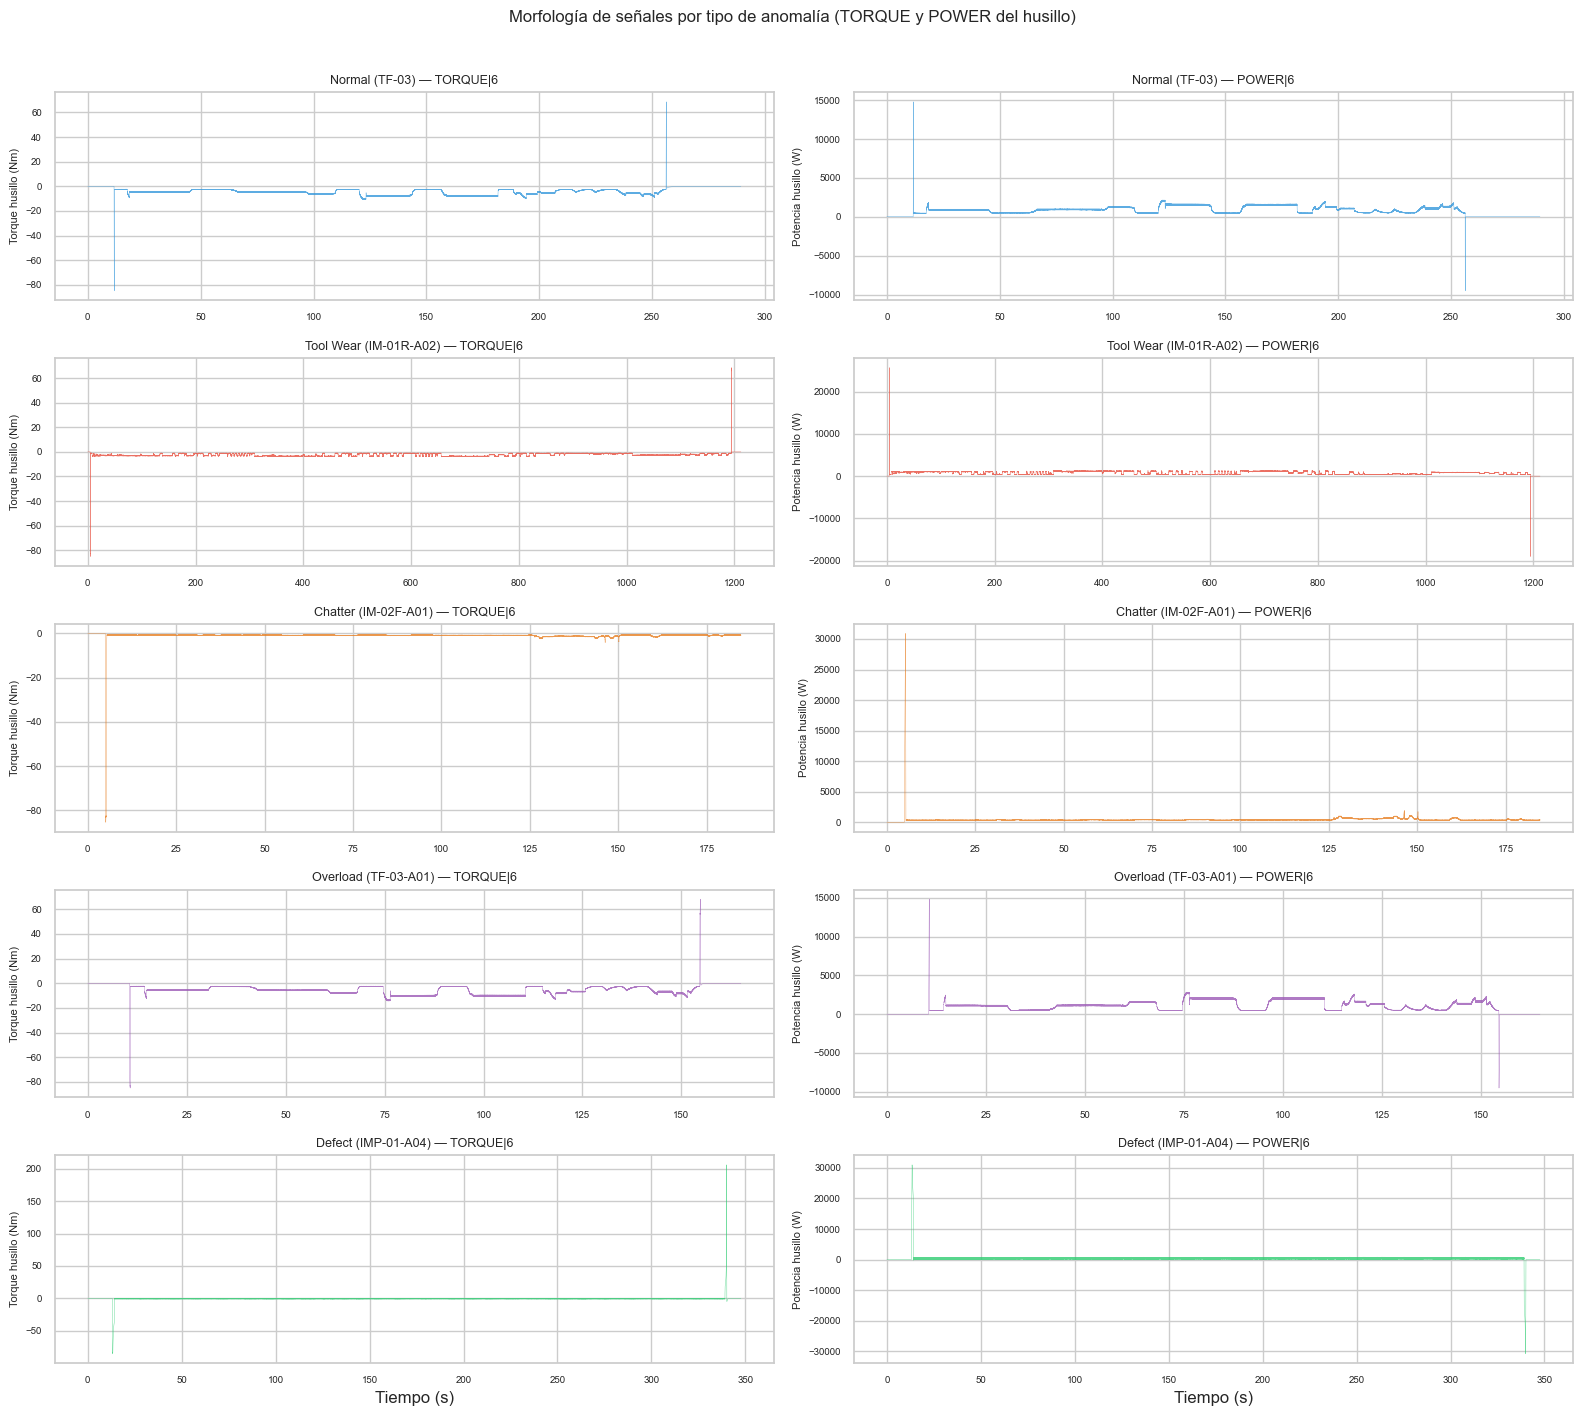

In [32]:
# Un experimento de cada tipo para visualizar la morfología
examples = {
    'Normal (TF-03)':       'TF-03',
    'Tool Wear (IM-01R-A02)': 'IM-01R-A02',
    'Chatter (IM-02F-A01)':  'IM-02F-A01',
    'Overload (TF-03-A01)':  'TF-03-A01',
    'Defect (IMP-01-A04)':   'IMP-01-A04',
}

fig, axes = plt.subplots(len(examples), 2, figsize=(16, 14), sharex=False)

for i, (label, trial) in enumerate(examples.items()):
    df = load_kit(trial)
    if df is None:
        continue
    color = FAULT_COLORS[FAULT_TYPE[trial]]
    t = np.arange(len(df)) / 500  # tiempo en segundos

    # TORQUE|6 (husillo)
    ax1 = axes[i, 0]
    if 'TORQUE|6' in df.columns:
        ax1.plot(t, df['TORQUE|6'], color=color, linewidth=0.3, alpha=0.8)
    ax1.set_ylabel('Torque husillo (Nm)', fontsize=8)
    ax1.set_title(f'{label} — TORQUE|6', fontsize=9)
    ax1.tick_params(labelsize=7)

    # POWER|6 (potencia del husillo — señal clave)
    ax2 = axes[i, 1]
    if 'POWER|6' in df.columns:
        ax2.plot(t, df['POWER|6'], color=color, linewidth=0.3, alpha=0.8)
    ax2.set_ylabel('Potencia husillo (W)', fontsize=8)
    ax2.set_title(f'{label} — POWER|6', fontsize=9)
    ax2.tick_params(labelsize=7)

    if i == len(examples)-1:
        ax1.set_xlabel('Tiempo (s)')
        ax2.set_xlabel('Tiempo (s)')

plt.suptitle('Morfología de señales por tipo de anomalía (TORQUE y POWER del husillo)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 3. Análisis espectral — firma de frecuencia del chatter

El **chatter** es una vibración regenerativa: la herramienta oscila a una frecuencia
de resonancia propia del sistema (típicamente decenas de Hz en CNC industriales a 500 Hz
de muestreo). Esta oscilación es **invisible en el dominio temporal** si se mira solo
la media o la desviación, pero aparece como un pico claro en el espectro de frecuencias.

Con 500 Hz de muestreo, podemos ver frecuencias hasta 250 Hz (Nyquist).
Comparamos el espectro de `TORQUE|6` y `POWER|6` entre un experimento normal y chatter.


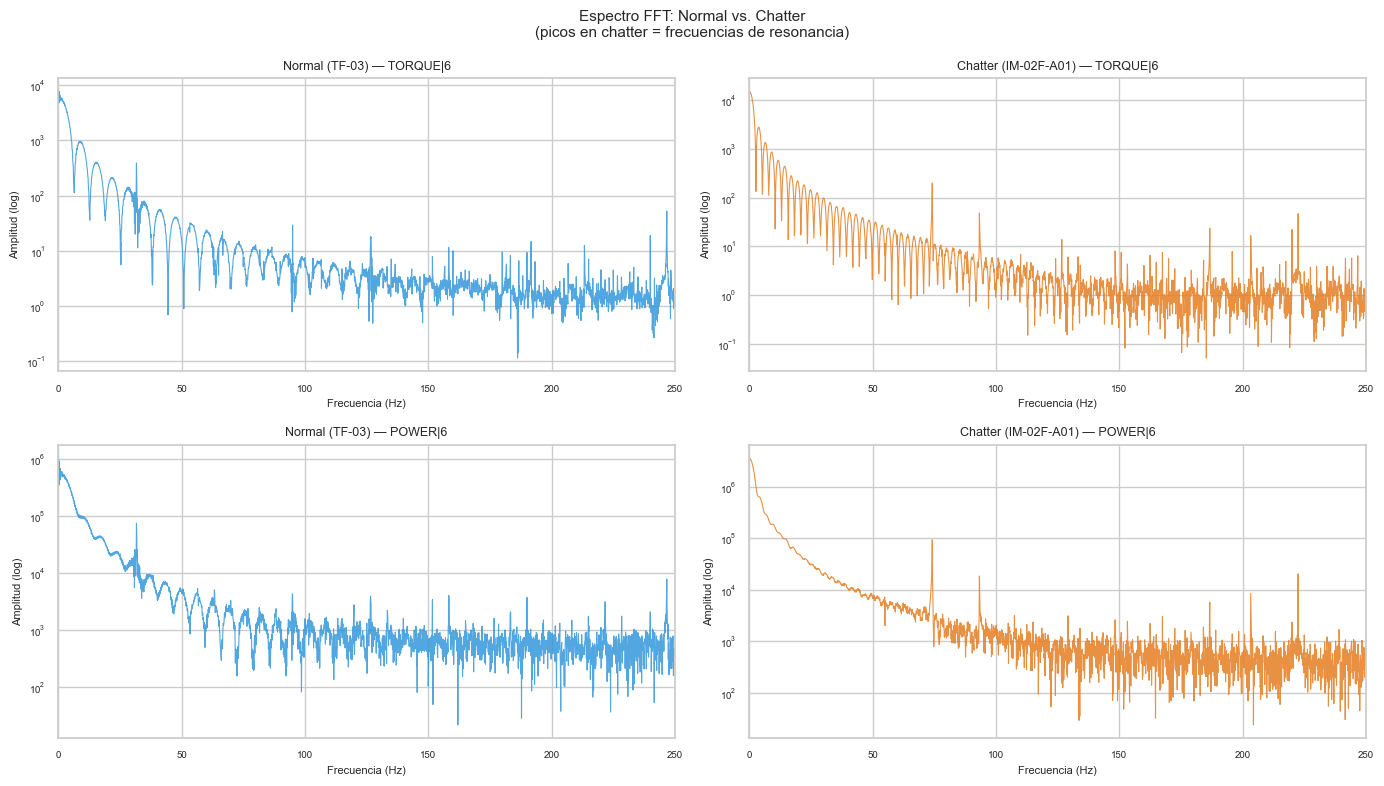

In [33]:
from scipy.fft import rfft, rfftfreq

fs = 500  # Hz de muestreo

def first_active_segment(series, n=5000, threshold=1.0):
    """Devuelve el primer segmento de n muestras donde la máquina está activa."""
    vals = series.values
    active = np.where(np.abs(vals) > threshold)[0]
    start = active[0] if len(active) else 0
    return vals[start:start + n]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for col_idx, trial in enumerate(['TF-03', 'IM-02F-A01']):
    df = load_kit(trial)
    label = 'Normal' if FAULT_TYPE[trial] == 0 else 'Chatter'
    color = FAULT_COLORS[FAULT_TYPE[trial]]

    for row_idx, sig in enumerate(['TORQUE|6', 'POWER|6']):
        ax = axes[row_idx, col_idx]
        if sig not in df.columns:
            continue
        segment = first_active_segment(df[sig].dropna(), n=5000)
        segment = segment - segment.mean()
        N = len(segment)
        yf = np.abs(rfft(segment))
        xf = rfftfreq(N, 1/fs)

        ax.semilogy(xf[1:], yf[1:] + 1e-10, color=color, linewidth=0.8, alpha=0.85)
        ax.set_title(f'{label} ({trial}) — {sig}', fontsize=9)
        ax.set_xlabel('Frecuencia (Hz)', fontsize=8)
        ax.set_ylabel('Amplitud (log)', fontsize=8)
        ax.set_xlim(0, 250)
        ax.tick_params(labelsize=7)

plt.suptitle('Espectro FFT: Normal vs. Chatter\n(picos en chatter = frecuencias de resonancia)',
             fontsize=11)
plt.tight_layout()
plt.show()

## 4. Distribuciones por tipo de anomalía

Comparamos las distribuciones de las señales más informativas del husillo
entre los 5 tipos de experimentos. Esto nos permite confirmar visualmente
qué señales discriminan mejor cada tipo de fallo antes de modelar.

**Lo que esperamos ver:**
- Tool Wear: TORQUE|6_rms más alto, CURRENT|6_rms más alto
- Chatter: POWER|6_std muy alto, TORQUE|6_kurtosis alto
- Overload: POWER|6_max disparado, LOAD|6_mean alto
- Workpiece Defect: TORQUE|6_max alto (pico al encontrar el defecto)


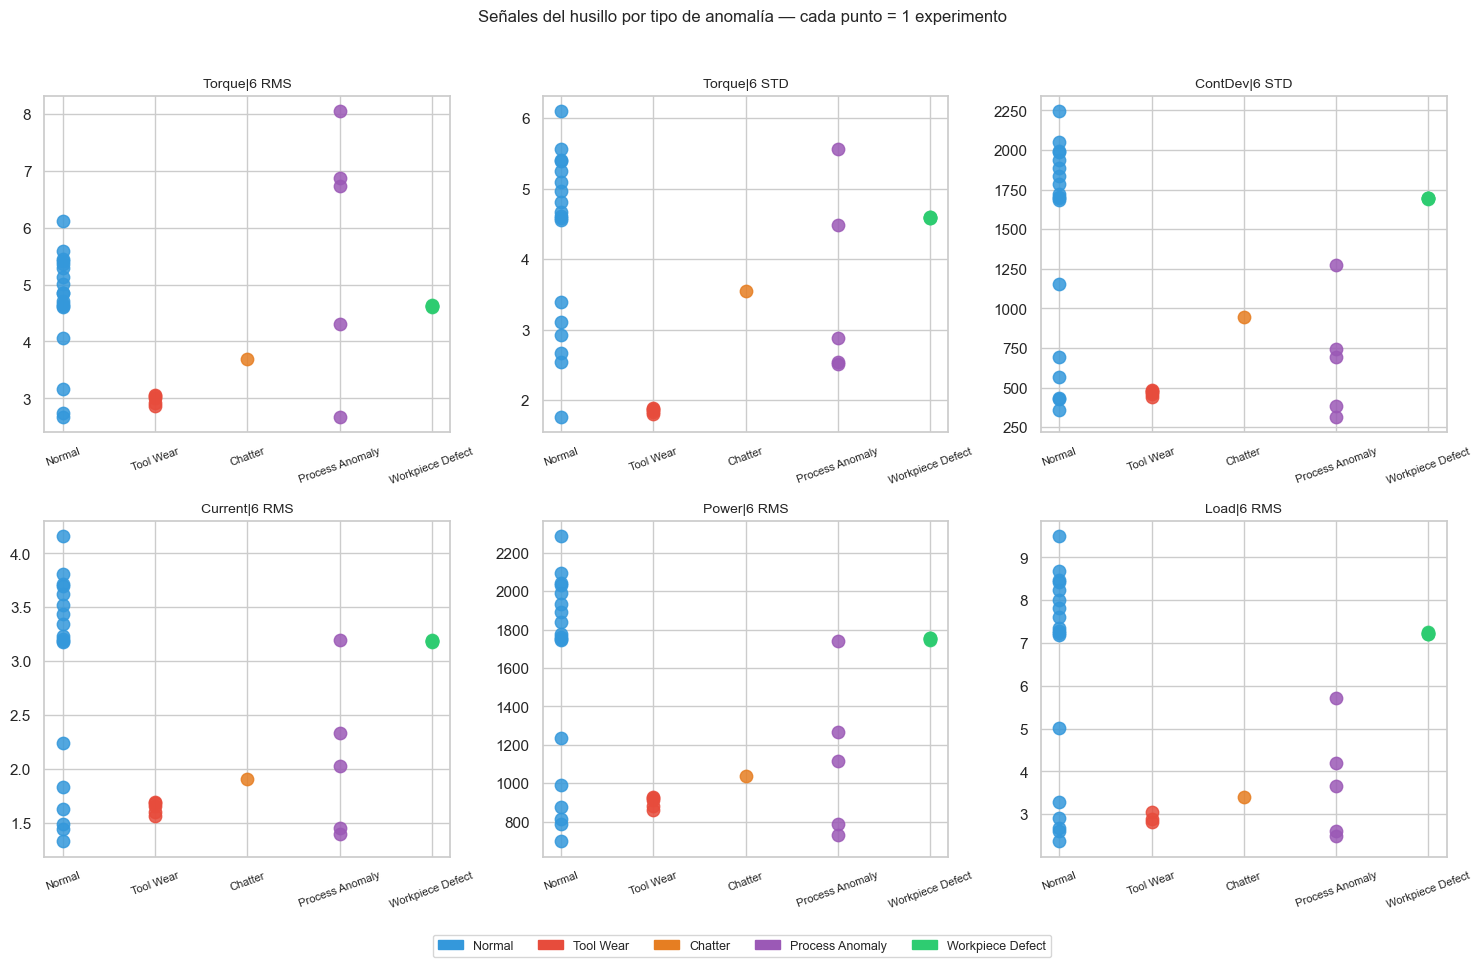

In [34]:
# Calculamos RMS y std por experimento para visualización rápida
quick_stats = []
for t in TRIALS:
    df = load_kit(t)
    if df is None: continue
    row = {'trial': t, 'fault_type': FAULT_TYPE[t],
           'fault_name': FAULT_NAMES[FAULT_TYPE[t]]}
    for sig in ['TORQUE|6','CURRENT|6','POWER|6','LOAD|6']:
        if sig not in df.columns: continue
        v = df[sig].dropna().values
        if len(v) == 0: continue
        row[f'{sig}_rms']  = np.sqrt(np.mean(v**2))
        row[f'{sig}_std']  = v.std()
        row[f'{sig}_max']  = np.abs(v).max()
        row[f'{sig}_kurt'] = pd.Series(v).kurtosis()
    quick_stats.append(row)

qs = pd.DataFrame(quick_stats)

plot_feats = ['TORQUE|6_rms','TORQUE|6_std','POWER|6_std',
              'CURRENT|6_rms','POWER|6_rms','LOAD|6_rms']
plot_labels = ['Torque|6 RMS','Torque|6 STD','ContDev|6 STD',
               'Current|6 RMS','Power|6 RMS','Load|6 RMS']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, feat, lbl in zip(axes, plot_feats, plot_labels):
    if feat not in qs.columns:
        ax.set_visible(False); continue
    for ft, name in FAULT_NAMES.items():
        subset = qs[qs['fault_type']==ft][feat].dropna()
        ax.scatter([name]*len(subset), subset,
                   color=FAULT_COLORS[ft], s=80, alpha=0.85, zorder=3,
                   label=name if feat == plot_feats[0] else '')
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20, labelsize=8)

plt.suptitle('Señales del husillo por tipo de anomalía — cada punto = 1 experimento',
             fontsize=12, y=1.02)
handles = [mpatches.Patch(color=FAULT_COLORS[k], label=v) for k,v in FAULT_NAMES.items()]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.show()

## 5. Correlaciones entre señales del husillo

Las correlaciones revelan qué señales aportan información redundante y cuáles son independientes.

En un CNC eléctrico la relación física es: `POWER = TORQUE × velocidad_angular`.
Por tanto TORQUE y POWER estarán muy correlacionados durante mecanizado activo.
CURRENT está directamente relacionado con TORQUE (motor eléctrico: τ ∝ I).

Lo interesante es comparar TORQUE vs POWER vs CURRENT: aunque físicamente relacionados,
cada uno captura un aspecto distinto del estado del husillo y puede discriminar
distintos tipos de fallo de forma complementaria.


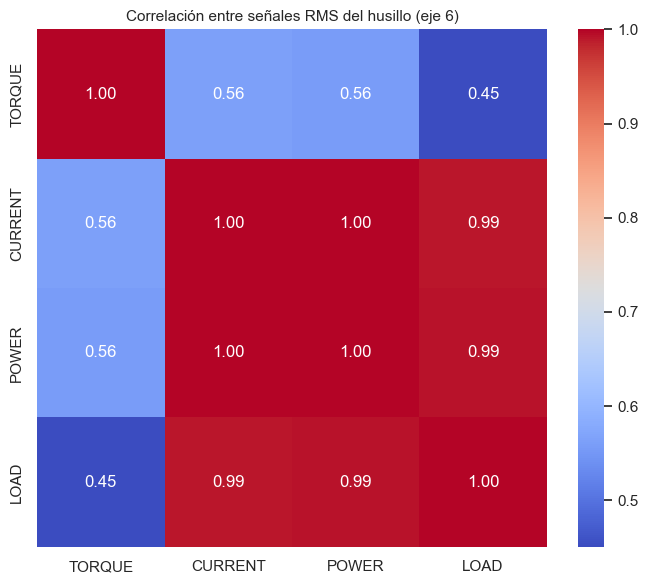

In [35]:
# Correlación entre estadísticos RMS de señales del husillo (eje 6)
rms_cols = [c for c in qs.columns if c.endswith('_rms') and '|6' in c]
if len(rms_cols) > 1:
    corr = qs[rms_cols].corr()
    labels_corr = [c.replace('|6_rms','') for c in rms_cols]
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                xticklabels=labels_corr, yticklabels=labels_corr, ax=ax)
    ax.set_title('Correlación entre señales RMS del husillo (eje 6)', fontsize=11)
    plt.tight_layout()
    plt.show()

## 6. Análisis de la potencia del husillo (POWER|6) — indicador de chatter y overload

`POWER|6` mide la potencia eléctrica consumida por el husillo.
En operación normal muestra un perfil estable durante el mecanizado.

En presencia de **chatter** (vibración resonante), la potencia oscila a la frecuencia
de resonancia — patrón perfectamente visible en el dominio temporal y en el espectro FFT.

En **overload** (TF-03-A01), la potencia sube bruscamente al aumentar la tasa de avance.


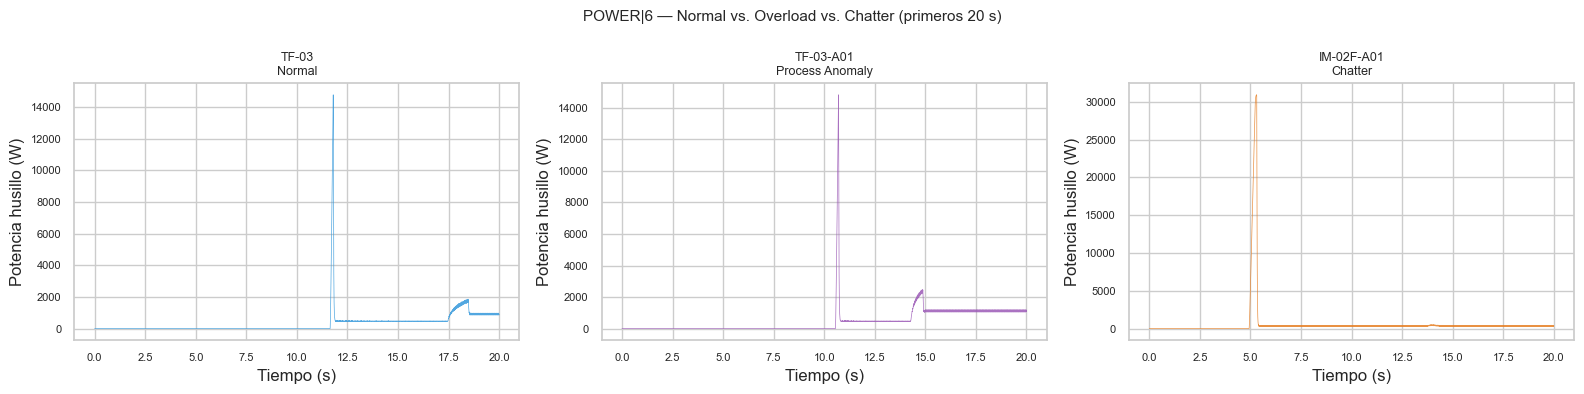


POWER|6 por tipo de fallo:
                  POWER|6_std  POWER|6_max
fault_name                                
Chatter              943.6572   30921.0205
Normal              1452.4557   27965.3931
Process Anomaly      680.0473   18966.7969
Tool Wear            466.8480   25636.5967
Workpiece Defect    1695.3434   30968.6279


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, trial in zip(axes, ['TF-03', 'TF-03-A01', 'IM-02F-A01']):
    df = load_kit(trial)
    if df is None or 'POWER|6' not in df.columns:
        continue
    t = np.arange(min(len(df), 10000)) / 500
    vals = df['POWER|6'].values[:10000]
    color = FAULT_COLORS[FAULT_TYPE[trial]]
    ax.plot(t, vals, color=color, linewidth=0.5, alpha=0.85)
    ax.set_title(f'{trial}\n{FAULT_NAMES[FAULT_TYPE[trial]]}', fontsize=9)
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Potencia husillo (W)')
    ax.tick_params(labelsize=8)

plt.suptitle('POWER|6 — Normal vs. Overload vs. Chatter (primeros 20 s)', fontsize=11)
plt.tight_layout()
plt.show()

# Estadísticos de POWER|6 por tipo
print('\nPOWER|6 por tipo de fallo:')
print(qs.groupby('fault_name')[['POWER|6_std','POWER|6_max']].mean().round(4))

## 7. Conclusiones EDA — Dataset KIT Industrial

- **18 ficheros disponibles** (8 normales, 10 anomalías de 4 tipos distintos)
- **TORQUE|6 y CURRENT|6** son las señales más discriminativas para tool wear y overload — directamente comparables con AI4I y SPARK respectivamente
- **POWER|6** es el indicador más claro de chatter y overload: std y amplitud espectral se disparan durante las oscilaciones de resonancia
- **El chatter tiene firma en frecuencia**: el espectro FFT muestra picos en frecuencias de resonancia que son invisibles en estadísticos temporales como mean o std
- **Workpiece defects** (cavidades, grietas) producen picos impulsivos breves → kurtosis y max son sus mejores detectores
- **POWER|6 ≈ TORQUE|6**: muy correlacionados, pero POWER conecta directamente con SPARK P_total y AI4I Power [W]

### Implicaciones para 02_03_Preprocesado_Industrial
- **Dominio temporal**: RMS, kurtosis, skewness, peak-to-peak, crest factor (además de mean/std/max)
- **Dominio de frecuencia**: energía espectral por bandas (0-25 Hz, 25-100 Hz, 100-250 Hz) y frecuencia dominante
- **POWER|6**: incluir features de variabilidad (std, kurtosis) — las más discriminativas para chatter
- **Etiquetas multi-clase**: Normal / Tool Wear / Chatter / Process Anomaly / Workpiece Defect
